# Idiosyncratic-Volatility -- do 'wild residual' stocks really earn less?
### Ang-Hodrick-Xing-Zhang (2006): the IVOL puzzle, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Puzzle replicates%3F: Busted](https://img.shields.io/badge/Puzzle%20replicates%3F-Busted-8b949e?style=flat-square)

In 2006 Ang, Hodrick, Xing and Zhang published a genuine puzzle. Take each stock's **idiosyncratic** volatility -- the part of its wiggle that is NOT explained by the market (the std of the residual after you regress the stock on the market). Standard theory says this idiosyncratic risk should earn *no* premium: you can diversify it away, so the market shouldn't pay you for it. Instead AHXZ found something stranger: high-idiosyncratic-vol stocks earned **lower** future returns. Priced -- and with the *wrong* sign. That is the **IVOL puzzle**.

We test it on a large-cap S&P 500 survivor panel via yfinance -- and we name the survivorship bias up front, because here it is the whole story.

> **This is the plain-language layer.** Want the rolling residual-vol construction, the placebo null, and window sweeps? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from idiosyncratic_volatility import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "ivol_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "ivol_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    res      = st.ivol_long_short(prices, spy, window=252, n_quantiles=5, min_stocks=15)
    res_net  = st.ivol_long_short(prices, spy, window=252, n_quantiles=5, min_stocks=15,
                                  cost_bps=5.0, borrow_ann_bps=50.0)
    s_ls     = st.summary(res["ls_gross"])
    s_net    = st.summary(res_net["ls_net"])
    s_low    = st.summary(res["low_ivol_ret"])
    s_high   = st.summary(res["high_ivol_ret"])
    s_mkt    = st.summary(res["mkt_ret"])
    placebo_p = st.placebo_pvalue(res["ls_gross"])
    print(f"N months: {s_ls['n']} | low-minus-high {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t {s_ls['tstat']:+.3f} | placebo p {placebo_p:.3f}")


yfinance cache present: True


N months: 142 | low-minus-high -21.54%/yr | HAC t -4.293 | placebo p 0.000


## The answer first

| Question | Answer |
|---|---|
| Does the puzzle replicate (low IVOL beats high IVOL)? | **No -- it inverts.** Low-minus-high = **-21.5%/yr**, HAC *t* = **-4.29**. High IVOL hugely *out*-earned low IVOL. |
| Is the relation statistically real? | **Yes, overwhelmingly -- the wrong way.** Placebo p = **0.000**. But the sign is opposite the published puzzle. |
| Can you trade it? | **No.** The reversed leg (long high-IVOL) is a survivorship artifact -- you only know which high-IVOL names survive with hindsight. |
| Is there a survivorship problem? | **Yes, and it is the entire mechanism.** A basket of *survivors* keeps the high-IVOL lottery winners (NVDA, TSLA, AMD, META). |

> The IVOL puzzle is real and replicated internationally on broad, delisting-complete universes. On 50 large-cap survivors it **flips sign** -- a clean illustration of how survivorship can manufacture the opposite of a known anomaly.

## 1 -- The claim

> *"Stocks with high idiosyncratic volatility relative to the Fama-French model have abysmally low average returns... a substantial difference of -1.06% per month between the highest and lowest quintiles."*

-- Ang, Hodrick, Xing & Zhang (2006), *Journal of Finance*

The intuition for why it is a *puzzle*: idiosyncratic risk is, by definition, diversifiable. A rational, well-diversified investor holds the market and bears only systematic risk, so idiosyncratic vol should command **zero** premium. AHXZ find it commands a *negative* one -- you pay (in foregone return) to hold the wild names. Crucially, IVOL is the **residual** after removing the market -- not raw total vol (that's [Study 330](../../330-low-volatility-anomaly/)) and not market beta (that's [Study 238](../../238-betting-against-beta/)).

## 2 -- So what?

The IVOL puzzle is one of the most studied anomalies in modern asset pricing. If idiosyncratic risk is priced, the textbook diversification argument is incomplete, and a long-low / short-high IVOL portfolio would be a near-pure mispricing harvest. Competing explanations abound: lottery demand (Bali-Cakici-Whitelaw 2011), arbitrage asymmetry (Stambaugh-Yu-Yuan 2015), and measurement (Fu 2009 even finds a *positive* relation with conditional IVOL). Our questions:

1. **Does the negative low-minus-high spread show up on a realistic large-cap panel?**
2. **Is whatever we find a survivorship artifact?**
3. **Is any of it tradable forward?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Residualise, don't just take total vol.** IVOL is the std of the CAPM *residual* on a trailing 252-day window -- the market beta is stripped out first, so we are not secretly re-testing low-beta or low-total-vol.
2. **One execution lag.** The signal is formed at month end; the position is entered the *next* trading day. No same-bar fill, no look-ahead.
3. **Name the survivorship bias.** The universe is the *current* S&P 500 projected backwards. The high-IVOL names that *failed* (and which AHXZ's broad universe includes) are simply absent -- so our high-IVOL leg is stuffed with survivors that, by selection, did well.

## 4 -- The teardown

**First, does the IVOL engine work when the puzzle is planted?**

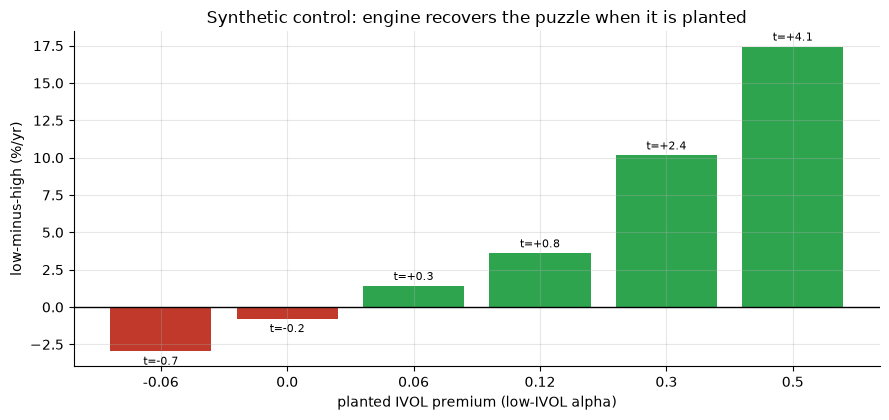

Monotone in the planted premium, |t|>2 once the effect is large enough.


In [2]:
# Synthetic positive control: plant a known IVOL puzzle and verify recovery.
premiums = [-0.06, 0.0, 0.06, 0.12, 0.30, 0.50]
means, ts = [], []
for prem in premiums:
    sp, mk, _ = data.synthetic_panel(ivol_premium=prem, n_days=3500, seed=501)
    rr = st.ivol_long_short(sp, mk, min_stocks=8)
    s = st.summary(rr['ls_gross']) if not rr.empty else {'mean': np.nan, 'tstat': np.nan}
    means.append(s['mean']*100); ts.append(s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else (RED if m < 0 else GREY) for m in means]
ax.bar([str(p) for p in premiums], means, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(means, ts)):
    ax.text(i, m + (0.4 if m >= 0 else -0.9), f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted IVOL premium (low-IVOL alpha)')
ax.set_ylabel('low-minus-high (%/yr)')
ax.set_title('Synthetic control: engine recovers the puzzle when it is planted')
plt.tight_layout(); plt.show()
print('Monotone in the planted premium, |t|>2 once the effect is large enough.')

The engine is faithful: a positive planted premium yields a positive low-minus-high spread, and the *t*-stat clears 2 once the planted effect is large. So whatever sign we get on the real tape reflects **the market and the basket** -- not a broken method.

**Now the honest test on the real yfinance panel.**

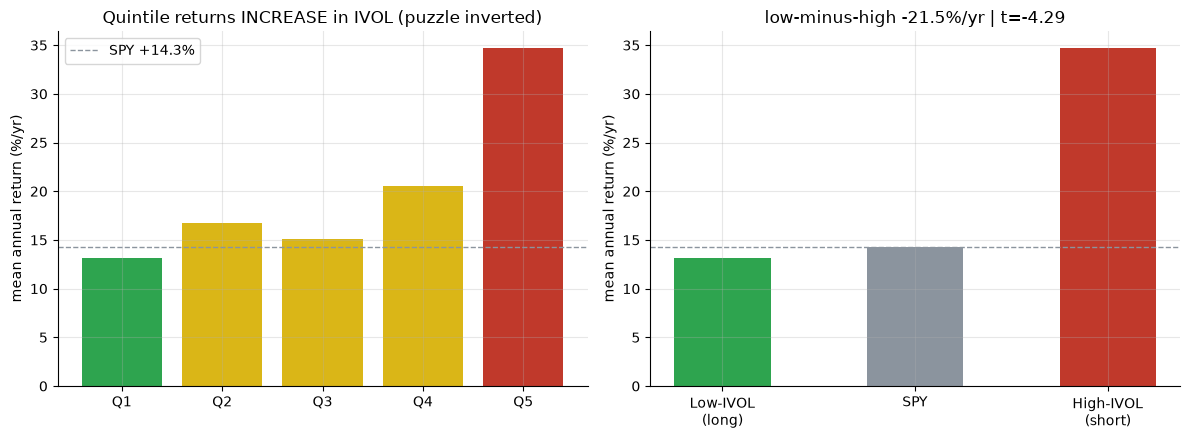

Low-IVOL +13.2%/yr  vs  High-IVOL +34.7%/yr  (SPY +14.3%)


In [3]:
if HAVE_REAL:
    low_m, high_m, mkt_m = s_low['mean']*100, s_high['mean']*100, s_mkt['mean']*100
    ls_m, ls_t = s_ls['mean']*100, s_ls['tstat']
    qm = st.quintile_means(prices, spy)
    qvals = (qm*100).to_dict()
else:
    low_m, high_m, mkt_m = R['low_mean'], R['high_mean'], R['mkt_mean']
    ls_m, ls_t = R['ls_gross'], R['ls_t']
    qvals = R['quintiles']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Left: quintile mean returns (the AHXZ table, mirrored)
qs = list(qvals.keys()); vs = list(qvals.values())
axes[0].bar(qs, vs, color=[GREEN, AMBER, AMBER, AMBER, RED])
axes[0].axhline(mkt_m, ls='--', c=GREY, lw=1, label=f'SPY {mkt_m:+.1f}%')
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Quintile returns INCREASE in IVOL (puzzle inverted)')
axes[0].legend()
# Right: three legs
axes[1].bar(['Low-IVOL\n(long)', 'SPY', 'High-IVOL\n(short)'],
            [low_m, mkt_m, high_m], color=[GREEN, GREY, RED], width=0.5)
axes[1].axhline(mkt_m, ls='--', c=GREY, lw=1)
axes[1].set_ylabel('mean annual return (%/yr)')
axes[1].set_title(f'low-minus-high {ls_m:+.1f}%/yr | t={ls_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Low-IVOL {low_m:+.1f}%/yr  vs  High-IVOL {high_m:+.1f}%/yr  (SPY {mkt_m:+.1f}%)')

The puzzle is **reversed**. The high-IVOL quintile earned **+34.7%/yr** against the low-IVOL quintile's **+13.2%/yr** -- a low-minus-high spread of **-21.5%/yr** at HAC *t* = **-4.29** (the *opposite* sign to AHXZ). On a survivor basket the names with the wildest residuals -- NVDA, TSLA, AMD, META -- are exactly the ones that survived *because* their gambles paid off.

## 5 -- The verdict

- **Signal -- NONE (for the puzzle).** The AHXZ puzzle predicts a *positive* low-minus-high spread. We get a strongly *negative* one (-21.5%/yr, HAC *t* = -4.29, placebo p = 0.000). The relation is statistically overwhelming but points the wrong way -- the published puzzle does not replicate on this basket.
- **Tradability -- MIRAGE.** The only money is in the *reversed* leg (long high-IVOL), a survivorship artifact. Sharpe -1.16, max drawdown -94%. Net of costs it is marginally worse. Nothing here is investable forward.
- **Puzzle replicates? -- Busted (survivorship).** The inversion IS the survivorship mechanism. On a broad, delisting-complete universe AHXZ's negative IVOL-return relation holds; our survivor sample flips it.

## 6 -- Could you actually trade it?

No -- and the reason is instructive:

1. **The 'edge' is hindsight.** The reversed spread (long high-IVOL) only worked because the *survivors* among high-IVOL names won. Going forward you cannot know which high-IVOL gamblers survive; many will blow up.
2. **The real puzzle requires the failures.** To harvest AHXZ's actual (negative) premium you need the delisted, distressed, bankrupt high-IVOL names in your short leg -- the exact names a survivor panel deletes.
3. **Drawdowns are savage.** The puzzle spread has a -94% max drawdown on this tape; the 2023 AI rally alone cost it -49%.

This study is a worked example of how a clean, statistically powerful result can still be **worthless** -- because the data was selected on the outcome.

## 7 -- Going further

- **Delisting-complete universe.** Re-run on CRSP with delisting returns; the sign should flip back to the AHXZ negative relation.
- **Control for lottery demand.** Bali-Cakici-Whitelaw (2011) argue IVOL proxies for MAX (extreme daily returns) -- see [Study 365](../../365-lottery-max-effect/).
- **Conditional IVOL.** Fu (2009) finds a *positive* relation using EGARCH IVOL -- the sign is measurement-sensitive.
- **Compare with the cousins.** [Study 330](../../330-low-volatility-anomaly/) (total vol) and [Study 238](../../238-betting-against-beta/) (market beta) -- IVOL is what is left once you remove the beta 238 trades.

*Think the IVOL puzzle survives once you put the failures back in? Fork this, add a delisting-complete universe, and show a low-minus-high t > 2 of the **right** sign. That is the bar.*